In [34]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())

2.21.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [72]:
from tensorflow import keras
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.models import Model
from keras.losses import MeanSquaredError
from keras.optimizers import Adam

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


In [36]:
IMAGE_PATH = "/mnt/e/Deep Learning/data/object-detection-akhavan/object-detection-notebooks/dataset/images"
ANNOTE_PATH = "/mnt/e/Deep Learning/data/object-detection-akhavan/object-detection-notebooks/dataset/airplanes.csv"

In [37]:
with open(ANNOTE_PATH, "r") as f:
    df = f.read()
    df = df.split("\n")
    df.pop()

In [38]:
IMAGES_PATH = [os.path.join(IMAGE_PATH, name) for name in os.listdir(IMAGE_PATH)]
images = [cv2.imread(path) for path in IMAGES_PATH]

In [39]:
for path in (os.listdir(IMAGE_PATH)):
    print(path)
    break

image_0001.jpg


In [40]:
print(f"Number of images: {len(os.listdir(IMAGE_PATH))}")
print(f"Number of rows in df: {len(df)}")

Number of images: 800
Number of rows in df: 800


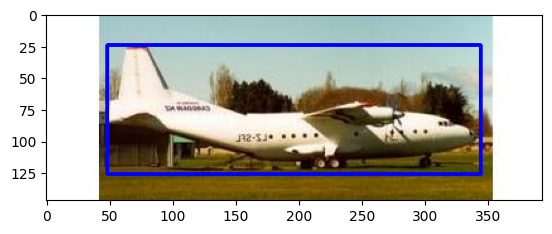

In [55]:
id = 5
image = images[id]
data = df[id]
name, x1, y1, x2, y2 = data.split(",")
x1 = int(x1)
y1 = int(y1)
x2 = int(x2)
y2 = int(y2)

cv2.namedWindow(f"Smple Image Number {id}")
cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
cv2.imshow(f"Smple Image Number {id}", image)
plt.imshow(image[..., ::-1])

cv2.waitKey()
cv2.destroyAllWindows()


In [62]:
data_iamge = []
targets = []
file_names = []

for row in df:
    name, x1, y1, x2, y2 = row.split(",")
    x1 = float(x1)
    y1 = float(y1)
    x2 = float(x2)
    y2 = float(y2)

    file_names.append(name)

    image_path = os.path.join(IMAGE_PATH, name)
    image = cv2.imread(image_path)

    h = image.shape[0]
    w = image.shape[1]

    x1_norm = x1 / w
    y1_norm = y1 / h
    x2_norm = x2 / w
    y2_norm = y2 / h
    targets.append((x1_norm, y1_norm, x2_norm, y2_norm))

    image = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    image = tf.keras.utils.img_to_array(image)
    data_iamge.append(image)

In [63]:
print(f"Number of images: {len(data_iamge)}")
print(f"Number of targets: {len(targets)}")

Number of images: 800
Number of targets: 800


In [64]:
data_iamge = np.array(data_iamge, dtype=np.float32) / 255
targets = np.array(targets, dtype=np.float32)

In [65]:
train_images, val_images, train_targets, val_targets, train_filenames, val_filenames = train_test_split(data_iamge, targets, file_names,test_size=0.1, random_state=42)

In [66]:
print("Input shape for training images:", train_images.shape)
print("Output shape for training targets:", train_targets.shape)
print("Input shape for validation images:", val_images.shape)
print("Output shape for validation targets:", val_targets.shape)

Input shape for training images: (720, 224, 224, 3)
Output shape for training targets: (720, 4)
Input shape for validation images: (80, 224, 224, 3)
Output shape for validation targets: (80, 4)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


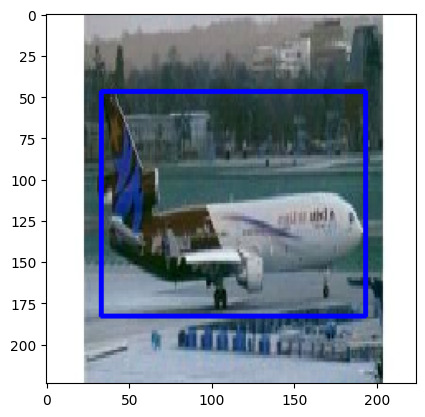

In [69]:
id = 20
image = train_images[id]
data = train_targets[id]
x1, y1, x2, y2 = data

h = image.shape[0]
w = image.shape[1]

x1 = int(x1 * w)
y1 = int(y1 * h)
x2 = int(x2 * w)
y2 = int(y2 * h)

cv2.namedWindow(f"Smple Image Number {id}")
cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
cv2.imshow(f"Smple Image Number {id}", image)
plt.imshow(image[..., ::-1])

cv2.waitKey()
cv2.destroyAllWindows()


In [ ]:
cnn_model = VGG16(include_top=False, weights="imagenet", input_tensor=tf.keras.layers.Input(shape=(224, 224, 3)))

In [ ]:
cnn_model.summary()

In [ ]:
cnn_model.trainable(False)

In [ ]:
input = tf.keras.layers.Input(shape=(224, 224, 3))
x = cnn_model(input)
x = keras.layers.Flatten(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dense(32, activation='relu')(x)
output = tf.keras.layers.Dense(4, activation='sigmoid')(x)

model = Model(input, output)
model.summary()

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=MeanSquaredError)

In [ ]:
history = model.fit(train_images, train_targets, validation_data=(val_images, val_targets), batch_size=32, epochs=200)

In [ ]:
model.save("/mnt/e/Deep Learning/models/localization.h5")

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) 
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()